# **1- INTRODUCTION**

# 🎮 Gaming & Mental Health Data Analysis

**Team:** The Outliers  
**Members:** Mohamed Bedier, Belal Elkhamisy, Shahd Mohamed, Youssef Talaat, Ebrahim Elnemr
**Supervised by:** 💌Dr. Amal Mahmoud 💌

---

### 📌 Project Introduction
This project performs an advanced data analysis lifecycle on a comprehensive dataset mapping the intersection between video gaming habits and human psychological, behavioral, and physical well-being. The core mission is to unveil empirical evidence on how intensive gaming correlates with physical strain, sleep architecture, academic/professional productivity, and potential addiction risks.

---

### 📊 Dataset Overview & Star Schema Architecture
The data has been engineered from a flat structure into an optimized **Star Schema Relational Database Engine**, separating descriptive attributes into specialized Dimensions linked to a central Fact Table.

#### 1. 🔲 Central Fact Table
* **`Fact_Gaming_Mental_Health`**: Holds quantitative metrics and keys.
  * **Keys:** `record_id` (PK), `Addiction_Id` (FK), `Physical_Id` (FK), `Sleep_Id` (FK), `Game_Id` (FK), `Platform_Id` (FK)
  * **Metrics & Measures:** `daily_gaming_hours`, `Gaming_Hours_Category`, `sleep_hours`, `academic_work_performance`, `grades_gpa`, `work_productivity_score`, `mood_state`, `mood_swing_frequency`, `weight_change_kg`, `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`, `monthly_game_spending_usd`, `years_gaming`, `Total_spent`, `Spend_Category`

#### 2. 🔷 Dimension Tables
* **`Dim_Platform`**: `Platform_Id` (PK), `gaming_platform`
* **`Dim_Game`**: `Game_Id` (PK), `game_genre`, `primary_game`
* **`Dim_Player`**: `record_id` (PK), `age`, `Age_Group`, `gender`, `Educational_State`
* **`Dim_Sleep`**: `Sleep_Id` (PK), `sleep_quality`, `sleep_disruption_frequency`, `Sleep_State`
* **`Dim_Addiction`**: `Addiction_Id` (PK), `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`, `gaming_addiction_risk_level`
* **`Dim_PhysicalStatus`**: `Physical_Id` (PK), `eye_strain`, `back_neck_pain`, `Physical_Pain`

---

### 🛠️ End-to-End Pipeline Roadmap
Our execution map covers the fundamental phases of professional data analytics:

* ✅ **Data Quality Check:** Validated empty cells and handled missing entries dynamically by transforming text blanks into appropriate database `NULL` markers (e.g., `grades_gpa` & `work_productivity_score`).
* ✅ **Statistical Outlier Validation:** Enforced formal empirical checks leveraging the Standard Normal Distribution criteria ($\mu \pm 3\sigma$) to verify data purity.
* ✅ **Feature Engineering:** Expanded structural depth by computing complex behavioral dimensions such as `Total_spent`, statistical `Spend_Category`, `sleep_states`, `Educational_State`, `Physical_Pain` indexes, and custom `Gaming_Hours_Category`.
* ✅ **Data Modeling & ETL:** Designed the relational database architecture and executed ordered insert sequences populating the dimensional nodes before generating the fact connections.
* ✅ **Exploratory Data Analysis (EDA):** Queried cross-dimensional behavior using complex relational SQL aggregations (`GROUP BY`, `JOIN`, `Subqueries`).
* 🔄 **Data Visualization & Storytelling:** Connecting Python environments directly to the database via `SQLAlchemy`, using `Pandas`, `Matplotlib`, and `Seaborn` to reveal high-impact strategic insights.

# **2- IMPORT LIBRARIES**

In [4]:
import pandas as pd
import numpy as np

# Visualization libraries for plotting charts
import matplotlib.pyplot as plt
import seaborn as sns

# Streamlit for building the web app dashboard
!pip install streamlit -q
import streamlit as st

# SQLAlchemy tools for DB connection and ORM mapping
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import declarative_base, relationship

# Library to generate and render ER diagrams
!pip install eralchemy2 -q
from eralchemy2 import render_er

# OS module for file paths and system operations
import os

print("Done")

Done


# **3- LOADING DATASET**

In [5]:
# Loading the dataset from a specific path
df = pd.read_csv(r"/content/Gaming & Mental_Health.csv")

# **4- BASIC INFORMATION ABOUT DATASET**

In [6]:
# Summary statistics for numerical columns (mean, min, max, etc.)
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [7]:
# Check the number of rows and columns (dimensions of the dataframe)
print(df.shape)

(1000, 27)


In [8]:
# Display dataframe summary, including data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [9]:
# Preview the first 5 rows of the dataset
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [10]:
# Preview the last 5 rows of the dataset
df.tail()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low
999,GD1000,29,Male,3.5,RPG,Cyberpunk 2077,Multi-platform,7.4,Good,Sometimes,...,False,False,False,0.0,9.3,2,10.9,25.20,19,Low


# **5- Descriptive Statistics of Numeric Variables**

In [11]:
# Calculate mean and standard deviation for gaming hours
mean = df["daily_gaming_hours"].mean()
std = df["daily_gaming_hours"].std()

# Define thresholds for outliers using the 3-sigma rule
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

# Filter the dataframe to isolate the outliers
outliers_df = df[(df["daily_gaming_hours"] < lower_bound) | (df["daily_gaming_hours"] > upper_bound)]

# Print the threshold limits and the count of detected outliers
print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Total Outliers Found : {len(outliers_df)}")

print("\n------------------------------------------------\n")

# Display outlier rows if they exist, otherwise confirm none were found
if not outliers_df.empty:
    display(outliers_df)
else:
    print("\nNo outliers found")

Lower Bound : -2.45
Upper Bound : 14.75
Total Outliers Found : 2

------------------------------------------------



,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
69,GD0070,18,Female,15.1,MMO,World of Warcraft,PC,4.8,Fair,Often,...,False,True,True,0.0,4.2,10,0.0,209.75,6,High
258,GD0259,15,Male,15.1,Strategy,Age of Empires,Multi-platform,5.7,Fair,Sometimes,...,False,True,True,1.5,0.7,9,0.0,435.38,2,Moderate


In [12]:
# Get all numerical columns in the dataframe
numeric_cols = df.select_dtypes(include=['number']).columns

print("🔍 Outliers Check (Standard Deviation Method):\n")

# Loop through each numerical column to detect outliers
for col in numeric_cols:

    # Calculate mean and standard deviation
    mean = df[col].mean()
    std = df[col].std()

    # Define lower and upper limits using the 3-sigma rule
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    # Filter data points that fall outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Print the outlier count for the current column
    print(f"📌 {col}: {len(outliers)} outliers found")

print("\n✅ Done checking all numerical columns!")

🔍 Outliers Check (Standard Deviation Method):

📌 age: 16 outliers found
📌 daily_gaming_hours: 2 outliers found
📌 sleep_hours: 0 outliers found
📌 grades_gpa: 0 outliers found
📌 work_productivity_score: 0 outliers found
📌 weight_change_kg: 17 outliers found
📌 exercise_hours_weekly: 2 outliers found
📌 social_isolation_score: 0 outliers found
📌 face_to_face_social_hours_weekly: 0 outliers found
📌 monthly_game_spending_usd: 21 outliers found
📌 years_gaming: 11 outliers found

✅ Done checking all numerical columns!


# **6- Exploratory Data Analysis**

In [13]:
# Count missing (null) values in each column
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [14]:
# Check for duplicate entries based on the unique record identifier
duplicates = df["record_id"].duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 0


# **7- Data Prepossessing**

In [15]:
# Create age groups based on predefined age ranges
df["age_group"] = df["age"].apply(
    lambda age: "Teenager" if age <= 18 else
              "Young_Adult" if age <= 28 else
              "Adult"
)

In [16]:
# View a subset of the dataframe to check the age bucketing results
df[["age", "age_group"]]

,age,age_group
0,17,Teenager
1,21,Young_Adult
2,23,Young_Adult
3,20,Young_Adult
4,18,Teenager
...,...,...
995,15,Teenager
996,18,Teenager
997,23,Young_Adult
998,18,Teenager


In [17]:
# Segment individuals into employment/academic statuses based on data availability
df["educational_state"] = df.apply(
    lambda row: "Working_Student" if pd.notna(row["grades_gpa"]) and pd.notna(row["work_productivity_score"]) else
                "Student" if pd.notna(row["grades_gpa"]) else
                "Worker" if pd.notna(row["work_productivity_score"]) else
                "Unknown",
    axis=1
)

In [18]:
# Verify the custom status logic by inspecting the relevant columns
df[["educational_state", "grades_gpa","work_productivity_score"]]

,educational_state,grades_gpa,work_productivity_score
0,Student,1.25,NaN
1,Working_Student,3.75,2.0
2,Worker,NaN,9.0
3,Working_Student,1.62,2.0
4,Student,2.44,NaN
...,...,...,...
995,Student,2.96,NaN
996,Student,3.42,NaN
997,Worker,NaN,3.0
998,Student,1.03,NaN


In [19]:
# Categorize sleep quality based on the total hours of sleep
df["sleep_state"] = df["sleep_hours"].apply(
    lambda sleep_hour: "Poor" if sleep_hour <= 4 else
              "Healthy" if sleep_hour <= 8 else
              "over_sleep"
)

In [20]:
# Verify the sleep bucketing results by inspecting the columns
df[["sleep_state", "sleep_hours"]]

,sleep_state,sleep_hours
0,Poor,3.7
1,Healthy,7.2
2,Healthy,4.4
3,Healthy,5.1
4,Poor,3.4
...,...,...
995,Healthy,4.1
996,Healthy,6.5
997,Poor,3.9
998,over_sleep,8.2


In [21]:
# Bin gaming hours dynamically using mean and standard deviation thresholds
avg_gaming_hours = df["daily_gaming_hours"].mean()
std_gaming_hours = df["daily_gaming_hours"].std()

df["gaming_hours_category"] = df["daily_gaming_hours"].apply(
    lambda gaming_hour: "Low" if gaming_hour < avg_gaming_hours else
              "Medium" if gaming_hour <= avg_gaming_hours + std_gaming_hours else
              "High" if gaming_hour <= avg_gaming_hours + 2*std_gaming_hours else
                "Very High"
)

In [22]:
# Verify the dynamic gaming categories by inspecting the columns
df[["gaming_hours_category", "daily_gaming_hours"]]

,gaming_hours_category,daily_gaming_hours
0,High,11.1
1,Low,3.0
2,Medium,7.6
3,Medium,7.2
4,Medium,6.8
...,...,...
995,Medium,8.6
996,Low,5.4
997,Medium,7.3
998,Low,3.1


In [23]:
# Derive lifetime gaming expenditure by extrapolating monthly spending over total gaming years
df["total_spent"] = (df["monthly_game_spending_usd"] * 12 * df["years_gaming"]).round(2)

In [24]:
# Inspect the derived lifetime expenditure alongside its base features to verify accuracy
df[["total_spent", "monthly_game_spending_usd","years_gaming"]]

,total_spent,monthly_game_spending_usd,years_gaming
0,13813.20,383.70,3
1,559.68,46.64,1
2,7258.32,100.81,6
3,4334.40,51.60,7
4,390.84,32.57,1
...,...,...,...
995,15355.44,426.54,3
996,7031.64,83.71,7
997,5316.00,88.60,5
998,2113.92,22.02,8


In [25]:
# Bin the lifetime expenditure dynamically using mean and standard deviation thresholds
avg_spent = df['total_spent'].mean()
std_spent = df['total_spent'].std()


df['Spend_Category'] = df['total_spent'].apply(
    lambda total_spent: 'Low' if total_spent <= avg_spent else
            'Mid' if total_spent <= (avg_spent + std_spent) else
            'High' if total_spent <= (avg_spent + 2 * std_spent) else
            'Very High'
)

In [26]:
# Verify the dynamic spending categories by inspecting the columns
df[['total_spent', 'Spend_Category']]

,total_spent,Spend_Category
0,13813.20,Mid
1,559.68,Low
2,7258.32,Mid
3,4334.40,Low
4,390.84,Low
...,...,...
995,15355.44,Mid
996,7031.64,Low
997,5316.00,Low
998,2113.92,Low


In [27]:
# Evaluate overall physical health risks based on visual and musculoskeletal strain indicators
df["physical_pain"] = df.apply(
    lambda row: "High_Risk" if row["eye_strain"] and row["back_neck_pain"] else
                "Moderate" if row["eye_strain"] or row["back_neck_pain"] else
                "Low_Risk",
    axis=1
)

In [28]:
# Inspect the derived physical pain risks alongside back and neck pain indicators to check consistency
df[['physical_pain', 'back_neck_pain']]

,physical_pain,back_neck_pain
0,Moderate,False
1,Low_Risk,False
2,Moderate,True
3,High_Risk,True
4,Low_Risk,False
...,...,...
995,High_Risk,True
996,Moderate,False
997,Moderate,True
998,Low_Risk,False


# **8- Data Modeling**

In [29]:
import pandas as pd
import sqlite3


# 1. Create an in-memory SQLite database connection
conn = sqlite3.connect(":memory:")

# 2. Write the main dataframe to a staging table in SQLite
df.to_sql("staging_df", conn, index=False, if_exists="replace")

# ==========================================
# 3. CREATE DIMENSION TABLES USING SQL
# ==========================================

# -- Dim Platform --
conn.execute("""
CREATE TABLE dim_platform (
    platform_id INTEGER PRIMARY KEY AUTOINCREMENT,
    gaming_platform TEXT UNIQUE
);
""")
conn.execute("""
INSERT INTO dim_platform (gaming_platform)
SELECT DISTINCT gaming_platform FROM staging_df WHERE gaming_platform IS NOT NULL;
""")

# -- Dim Game --
conn.execute("""
CREATE TABLE dim_game (
    game_id INTEGER PRIMARY KEY AUTOINCREMENT,
    game_genre TEXT,
    primary_game TEXT,
    UNIQUE(game_genre, primary_game)
);
""")
conn.execute("""
INSERT INTO dim_game (game_genre, primary_game)
SELECT DISTINCT game_genre, primary_game FROM staging_df;
""")

# -- Dim Sleep --
conn.execute("""
CREATE TABLE dim_sleep (
    sleep_id INTEGER PRIMARY KEY AUTOINCREMENT,
    sleep_quality TEXT,
    sleep_disruption_frequency TEXT,
    sleep_state TEXT,
    UNIQUE(sleep_quality, sleep_disruption_frequency, sleep_state)
);
""")
conn.execute("""
INSERT INTO dim_sleep (sleep_quality, sleep_disruption_frequency, sleep_state)
SELECT DISTINCT sleep_quality, sleep_disruption_frequency, sleep_state FROM staging_df;
""")

# -- Dim Addiction --
conn.execute("""
CREATE TABLE dim_addiction (
    addiction_id INTEGER PRIMARY KEY AUTOINCREMENT,
    withdrawal_symptoms TEXT,
    loss_of_other_interests TEXT,
    continued_despite_problems TEXT,
    gaming_addiction_risk_level TEXT,
    UNIQUE(withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level)
);
""")
conn.execute("""
INSERT INTO dim_addiction (withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level)
SELECT DISTINCT withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level FROM staging_df;
""")

# -- Dim Physical --
conn.execute("""
CREATE TABLE dim_physical (
    physical_id INTEGER PRIMARY KEY AUTOINCREMENT,
    eye_strain TEXT,
    back_neck_pain TEXT,
    physical_pain TEXT,
    UNIQUE(eye_strain, back_neck_pain, physical_pain)
);
""")
conn.execute("""
INSERT INTO dim_physical (eye_strain, back_neck_pain, physical_pain)
SELECT DISTINCT eye_strain, back_neck_pain, physical_pain FROM staging_df;
""")

# -- Dim Player --
conn.execute("""
CREATE TABLE dim_player (
    record_id TEXT PRIMARY KEY,
    age INTEGER,
    age_group TEXT,
    gender TEXT,
    educational_state TEXT
);
""")
conn.execute("""
INSERT INTO dim_player (record_id, age, age_group, gender, educational_state)
SELECT DISTINCT record_id, age, age_group, gender, educational_state FROM staging_df;
""")


# ==========================================
# 4. CREATE FACT TABLE USING SQL JOINS
# ==========================================

fact_table_query = """
CREATE TABLE fact_table AS
SELECT
    s.record_id,
    s.gender,

    -- Foreign Keys from Dimension Tables
    dp.platform_id,
    g.game_id,
    sl.sleep_id,
    a.addiction_id,
    ph.physical_id,

    -- Gaming Measures
    s.daily_gaming_hours,
    s.gaming_hours_category,
    s.years_gaming,

    -- Spending Measures
    s.monthly_game_spending_usd,
    s.total_spent,
    s.Spend_Category,

    -- Sleep Measures
    s.sleep_hours,
    s.sleep_state,

    -- Academic and Work Measures
    s.academic_work_performance,
    s.grades_gpa,
    s.work_productivity_score,

    -- Mental Health Measures
    s.mood_state,
    s.mood_swing_frequency,

    -- Physical Health Measures
    s.weight_change_kg,
    s.exercise_hours_weekly,

    -- Social Measures
    s.social_isolation_score,
    s.face_to_face_social_hours_weekly

FROM staging_df s
LEFT JOIN dim_platform dp ON s.gaming_platform = dp.gaming_platform
LEFT JOIN dim_game g     ON s.game_genre = g.game_genre AND s.primary_game = g.primary_game
LEFT JOIN dim_sleep sl   ON s.sleep_quality = sl.sleep_quality AND s.sleep_disruption_frequency = sl.sleep_disruption_frequency AND s.sleep_state = sl.sleep_state
LEFT JOIN dim_addiction a ON s.withdrawal_symptoms = a.withdrawal_symptoms
                        AND s.loss_of_other_interests = a.loss_of_other_interests
                        AND s.continued_despite_problems = a.continued_despite_problems
                        AND s.gaming_addiction_risk_level = a.gaming_addiction_risk_level
LEFT JOIN dim_physical ph ON s.eye_strain = ph.eye_strain
                        AND s.back_neck_pain = ph.back_neck_pain
                        AND s.physical_pain = ph.physical_pain;
"""

conn.execute(fact_table_query)


# ==========================================
# 5. EXTRACT BACK TO PANDAS DATAFRAMES
# ==========================================

dim_platform = pd.read_sql_query("SELECT * FROM dim_platform;", conn)
dim_game = pd.read_sql_query("SELECT * FROM dim_game;", conn)
dim_sleep = pd.read_sql_query("SELECT * FROM dim_sleep;", conn)
dim_addiction = pd.read_sql_query("SELECT * FROM dim_addiction;", conn)
dim_physical = pd.read_sql_query("SELECT * FROM dim_physical;", conn)
dim_player = pd.read_sql_query("SELECT * FROM dim_player;", conn)
fact_table = pd.read_sql_query("SELECT * FROM fact_table;", conn)

# Close the database connection
conn.close()

# **9- Diagram for Data Modeling**

In [30]:
# Install Graphviz system-level dependencies required for rendering ERD diagrams visually
!apt-get install graphviz graphviz-dev -y
# Install the required Python libraries for data manipulation (pandas), ORM mapping (SQLAlchemy), and ERD generation (eralchemy2)
!pip install eralchemy2 sqlalchemy pandas

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 3 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main a

In [31]:
import os
import pandas as pd
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import declarative_base, relationship
from eralchemy2 import render_er

# 1. Initialize SQLAlchemy Base
Base = declarative_base()

# ==========================================
# 2. DEFINE DIMENSION TABLES (CLASSES)
# ==========================================

class DimPlatform(Base):
    __tablename__ = 'dim_platform'
    platform_id = Column(Integer, primary_key=True, autoincrement=True)
    gaming_platform = Column(String, unique=True)

    # Relationship to Fact Table
    facts = relationship("FactGamingMentalHealth", back_populates="platform")

class DimGame(Base):
    __tablename__ = 'dim_game'
    game_id = Column(Integer, primary_key=True, autoincrement=True)
    game_genre = Column(String)
    primary_game = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="game")

class DimSleep(Base):
    __tablename__ = 'dim_sleep'
    sleep_id = Column(Integer, primary_key=True, autoincrement=True)
    sleep_quality = Column(String)
    sleep_disruption_frequency = Column(String)
    sleep_state = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="sleep")

class DimAddiction(Base):
    __tablename__ = 'dim_addiction'
    addiction_id = Column(Integer, primary_key=True, autoincrement=True)
    withdrawal_symptoms = Column(String)
    loss_of_other_interests = Column(String)
    continued_despite_problems = Column(String)
    gaming_addiction_risk_level = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="addiction")

class DimPhysical(Base):
    __tablename__ = 'dim_physical'
    physical_id = Column(Integer, primary_key=True, autoincrement=True)
    eye_strain = Column(String)
    back_neck_pain = Column(String)
    physical_pain = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="physical")

class DimPlayer(Base):
    __tablename__ = 'dim_player'
    record_id = Column(String, primary_key=True)
    age = Column(Integer)
    age_group = Column(String)
    gender = Column(String)
    educational_state = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="player")


# ==========================================
# 3. DEFINE THE CENTRAL FACT TABLE
# ==========================================

class FactGamingMentalHealth(Base):
    __tablename__ = 'fact_table'

    # Primary Key / Composite Key base
    record_id = Column(String, ForeignKey('dim_player.record_id'), primary_key=True)
    gender = Column(String)

    # Foreign Keys connecting to Dimensions
    platform_id = Column(Integer, ForeignKey('dim_platform.platform_id'))
    game_id = Column(Integer, ForeignKey('dim_game.game_id'))
    sleep_id = Column(Integer, ForeignKey('dim_sleep.sleep_id'))
    addiction_id = Column(Integer, ForeignKey('dim_addiction.addiction_id'))
    physical_id = Column(Integer, ForeignKey('dim_physical.physical_id'))

    # Gaming Measures
    daily_gaming_hours = Column(Float)
    gaming_hours_category = Column(String)
    years_gaming = Column(Integer)

    # Spending Measures
    monthly_game_spending_usd = Column(Float)
    total_spent = Column(Float)
    Spend_Category = Column(String)

    # Sleep Measures
    sleep_hours = Column(Float)
    sleep_state = Column(String)

    # Academic and Work Measures
    academic_work_performance = Column(String)
    grades_gpa = Column(Float)
    work_productivity_score = Column(Float)

    # Mental Health Measures
    mood_state = Column(String)
    mood_swing_frequency = Column(String)

    # Physical Health Measures
    weight_change_kg = Column(Float)
    exercise_hours_weekly = Column(Float)

    # Social Measures
    social_isolation_score = Column(Float)
    face_to_face_social_hours_weekly = Column(Float)

    # Define Relationships back to Dimensions for ORM mapping
    player = relationship("DimPlayer", back_populates="facts")
    platform = relationship("DimPlatform", back_populates="facts")
    game = relationship("DimGame", back_populates="facts")
    sleep = relationship("DimSleep", back_populates="facts")
    addiction = relationship("DimAddiction", back_populates="facts")
    physical = relationship("DimPhysical", back_populates="facts")


# ==========================================
# 4. GENERATE THE ER DIAGRAM IMAGE
# ==========================================

# Create a local SQLite database file to map the schema
output_image = "star_schema.png"
db_uri = "sqlite:///temp_gaming_schema.db"
engine = create_engine(db_uri)

# Create all tables in the database
Base.metadata.create_all(engine)

print("Generating ERD Diagram using eralchemy2...")
try:
    # Render the schema directly into a PNG file
    render_er(db_uri, output_image)
    print(f" Success! ERD saved as '{output_image}' in your directory.")

    # Clean up the temporary database file
    if os.path.exists("temp_gaming_schema.db"):
        os.remove("temp_gaming_schema.db")

except Exception as e:
    print(f"Error generating diagram: {e}")

Generating ERD Diagram using eralchemy2...
 Success! ERD saved as 'star_schema.png' in your directory.


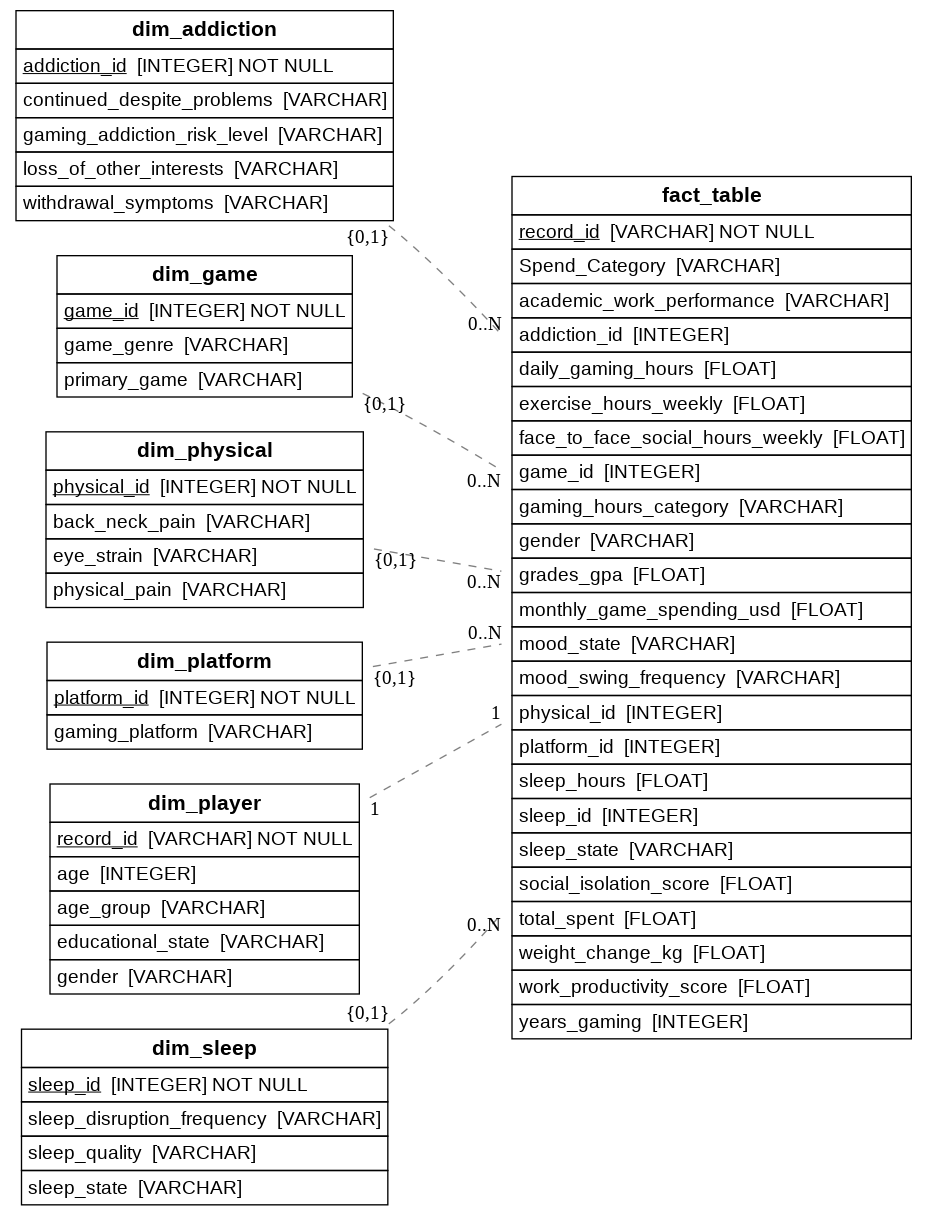

In [32]:
from IPython.display import Image, display

# عرض الصورة مباشرة في الـ Output
display(Image("star_schema.png"))

# **10- KPIs**

In [33]:
kpis = pd.DataFrame({
    "total_players": [len(fact_table)],
    "avg_daily_gaming_hours": [fact_table["daily_gaming_hours"].mean().round(1)],
    "avg_sleep_hours": [fact_table["sleep_hours"].mean().round(1)],
    "avg_social_isolation": [fact_table["social_isolation_score"].mean().round(1)],
    "avg_monthly_spending": [fact_table["monthly_game_spending_usd"].mean().round(1)],
    "total_spending": [fact_table["total_spent"].sum().round(1)]
})

kpis

,total_players,avg_daily_gaming_hours,avg_sleep_hours,avg_social_isolation,avg_monthly_spending,total_spending
0,1000,6.2,5.7,3.9,105.2,7204598.5


# **11- Data Analysis**

In [34]:
addiction_analysis = (
    fact_table.merge(dim_addiction, on="addiction_id", how="inner")
    .groupby("gaming_addiction_risk_level")
    .agg(
        players=("record_id", "count"),
        avg_gaming_hours=("daily_gaming_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
)

addiction_analysis

,gaming_addiction_risk_level,players,avg_gaming_hours,avg_social_isolation,avg_spending
0,High,154,8.698701,5.532468,157.626494
1,Low,514,4.020428,2.478599,47.993249
2,Moderate,190,7.004211,4.331579,102.727263
3,Severe,142,9.961268,6.500000,258.862958


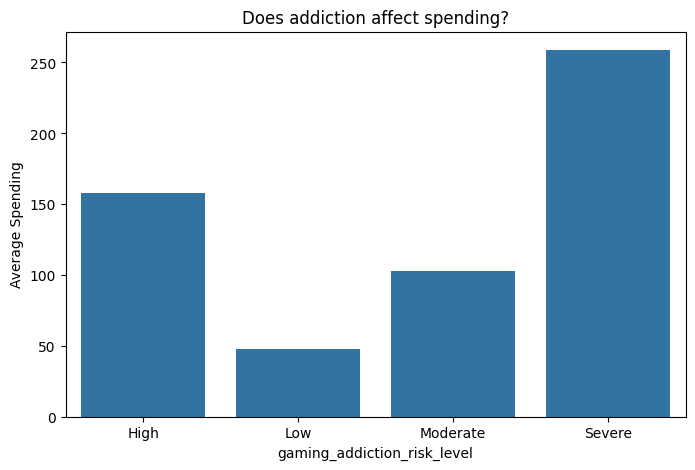

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=addiction_analysis,
    x="gaming_addiction_risk_level",
    y="avg_spending"
)

plt.title("Does addiction affect spending?")
plt.ylabel("Average Spending")
plt.show()

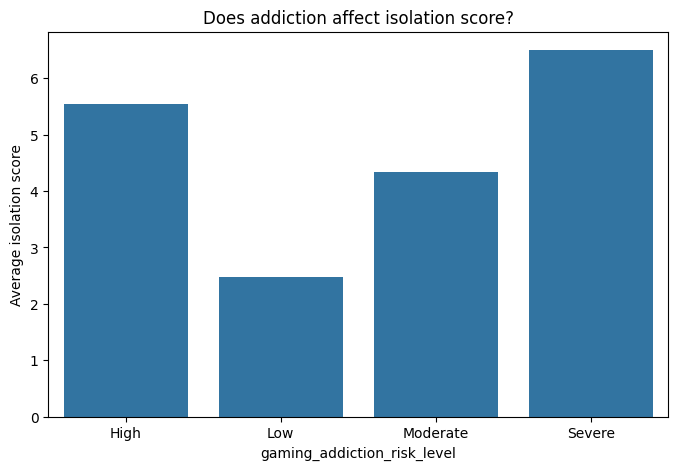

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=addiction_analysis,
    x="gaming_addiction_risk_level",
    y="avg_social_isolation"
)

plt.title("Does addiction affect isolation score?")
plt.ylabel("Average isolation score")
plt.show()

In [37]:
gaming_sleep_analysis = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_state_y")
    .agg(
        players=("record_id", "count"),
        avg_sleep_hours=("sleep_hours", "mean"),
        weight_change_kg=("weight_change_kg", "mean"),
        avg_exercise_hours=("exercise_hours_weekly", "mean"),
    )
    .reset_index()
)

gaming_sleep_analysis

,sleep_state_y,players,avg_sleep_hours,weight_change_kg,avg_exercise_hours
0,Healthy,764,5.835864,1.507199,6.935864
1,Poor,147,3.536054,2.129932,5.800000
2,over_sleep,89,8.535955,0.548315,8.924719


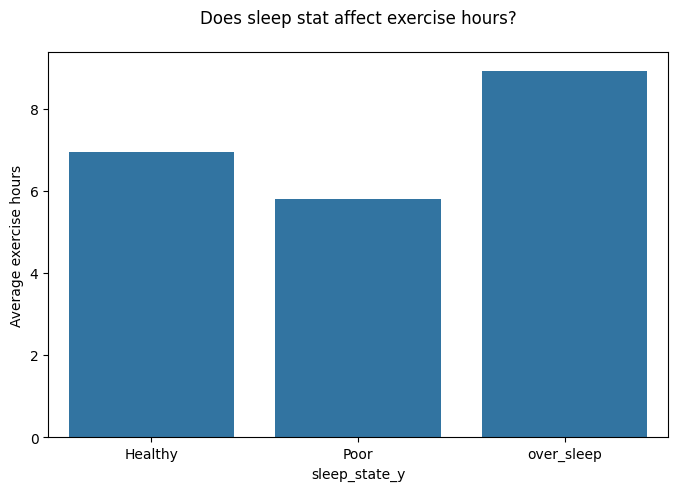

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gaming_sleep_analysis,
    x="sleep_state_y",
    y="avg_exercise_hours"
)

plt.title("Does sleep stat affect exercise hours?\n")
plt.ylabel("Average exercise hours")
plt.show()

In [39]:
gaming_sleep_analysis2 = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_quality")
    .agg(
        avg_daily_hours=("daily_gaming_hours", "mean"),
    )
    .reset_index()
)

gaming_sleep_analysis2

,sleep_quality,avg_daily_hours
0,Fair,5.433447
1,Good,4.049057
2,Insomnia,8.651351
3,Poor,6.937456
4,Very Poor,8.100571


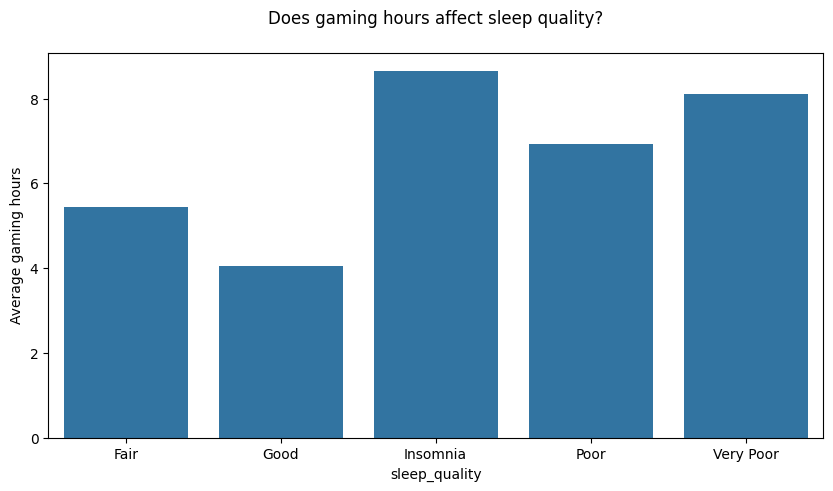

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=gaming_sleep_analysis2,
    x="sleep_quality",
    y="avg_daily_hours"
)

plt.title("Does gaming hours affect sleep quality?\n")
plt.ylabel("Average gaming hours")
plt.show()

In [41]:
platform_analysis = (
    fact_table.merge(dim_platform, on="platform_id", how="inner")
    .groupby("gaming_platform")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "sum"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
)

platform_analysis

,gaming_platform,players,sum_gaming_hours,avg_social_isolation,avg_spending
0,Console,237,1500.5,3.995781,109.689241
1,Mobile,262,1547.4,3.721374,97.310000
2,Multi-platform,260,1629.9,3.911538,106.629231
3,PC,241,1473.6,3.871369,107.902739


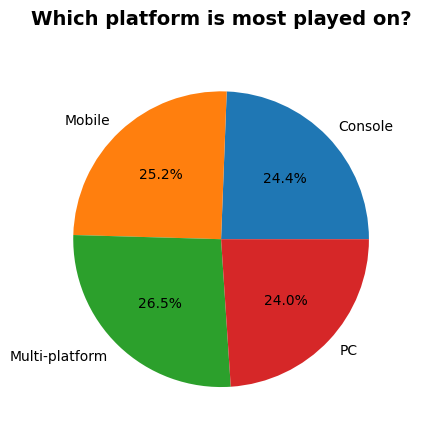

In [42]:
plt.pie(
    x=platform_analysis["sum_gaming_hours"],
    labels=platform_analysis["gaming_platform"],
    autopct='%1.1f%%'
)

plt.title("Which platform is most played on?\n", fontsize=14, fontweight='bold')
plt.show()

In [43]:
age_analysis = (
    fact_table.merge(dim_player, on="record_id", how="inner")
   .groupby("age_group")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean")
    )
    .reset_index()
)

age_analysis

,age_group,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation
0,Adult,50,5.558000,6.004000,3.540000
1,Teenager,326,6.117791,5.739877,3.769939
2,Young_Adult,624,6.216506,5.715865,3.951923


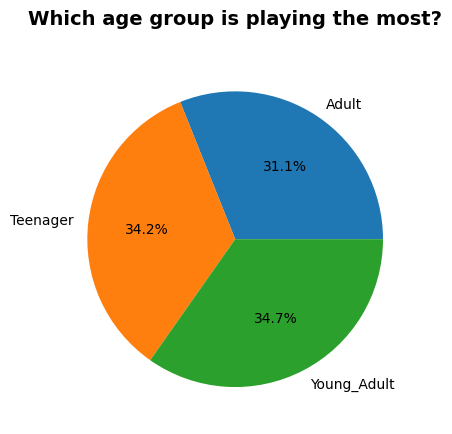

In [44]:
plt.pie(
    x=age_analysis["sum_gaming_hours"],
    labels=age_analysis["age_group"],
    autopct='%1.1f%%'
)

plt.title("Which age group is playing the most?\n", fontsize=14, fontweight='bold')
plt.show()

In [45]:
genre_addiction = (
    fact_table.merge(dim_game, on="game_id", how="inner")
    .groupby("game_genre")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        total_spending=("monthly_game_spending_usd", "sum")
    )
    .reset_index()
)
genre_addiction

,game_genre,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation,total_spending
0,Battle Royale,141,6.304965,5.758865,3.957447,13840.60
1,FPS,134,5.846269,5.926866,3.708955,12560.16
2,MMO,143,6.222378,5.774126,3.944056,16368.79
3,MOBA,156,5.962179,5.791026,3.653846,17021.29
4,Mobile Games,139,6.233094,5.706475,3.884892,13583.12
5,RPG,146,6.130137,5.640411,4.020548,15607.52
6,Strategy,141,6.366667,5.575177,3.943262,16238.25


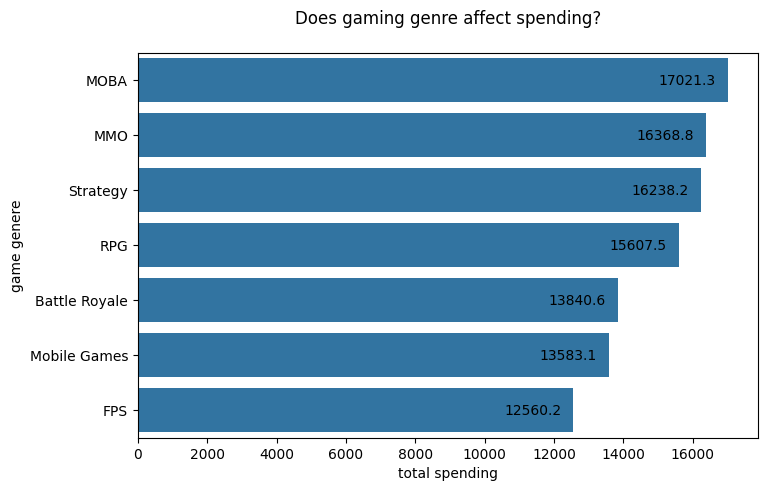

In [46]:
sorted_genres = genre_addiction.sort_values(by="total_spending", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=sorted_genres,
    x="total_spending",
    y="game_genre"
)


for container in ax.containers:
    ax.bar_label(
        container,
        padding=-50,
    )

plt.title("Does gaming genre affect spending?\n")
plt.xlabel("total spending")
plt.ylabel("game genere")
plt.show()

In [47]:
spending_analysis = (
    fact_table.groupby("Spend_Category")
    .agg(
        players=("record_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_total_spent", ascending=False)
)
spending_analysis

,Spend_Category,players,avg_total_spent,avg_gaming_hours
3,Very High,45,44358.75,10.47
0,High,48,22419.01,9.17
2,Mid,208,11063.87,7.71
1,Low,699,2619.54,5.20


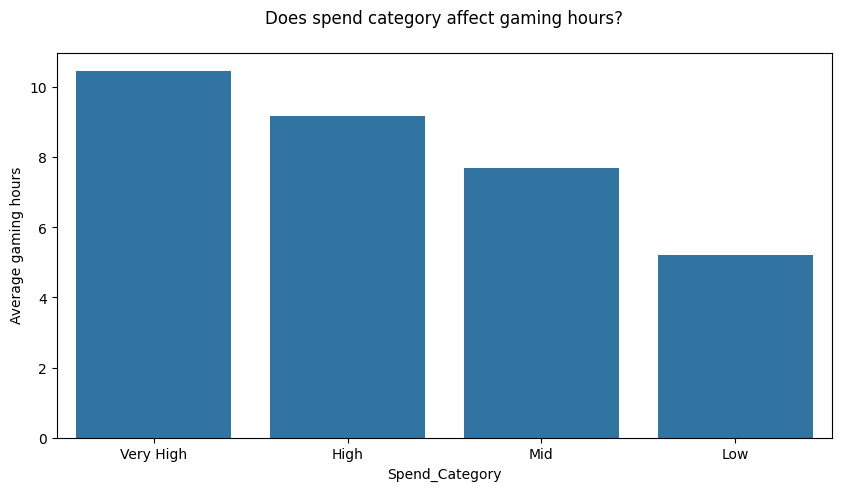

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=spending_analysis,
    x="Spend_Category",
    y="avg_gaming_hours"
)

plt.title("Does spend category affect gaming hours?\n")
plt.ylabel("Average gaming hours")
plt.show()

gaming_addiction_risk_level  High  Low  Moderate  Severe
gaming_platform                                         
Console                        44  109        46      38
Mobile                         44  135        53      30
Multi-platform                 36  135        48      41
PC                             30  135        43      33


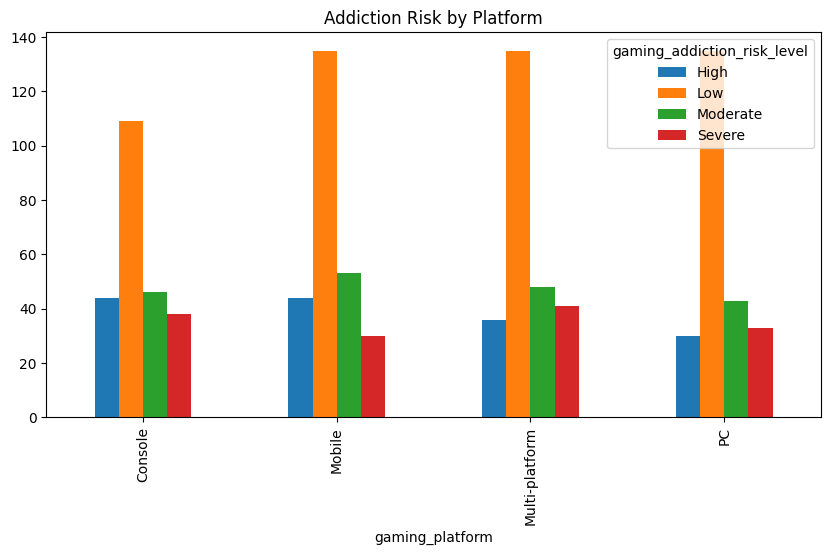

In [49]:
platform_addiction_df = fact_table.merge(dim_platform, on='platform_id', how='inner')
platform_addiction_df = platform_addiction_df.merge(dim_addiction, on='addiction_id', how='inner')

platform_risk = pd.crosstab(
    platform_addiction_df["gaming_platform"],
    platform_addiction_df["gaming_addiction_risk_level"]
)

print(platform_risk)

platform_risk.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Addiction Risk by Platform")
plt.show()

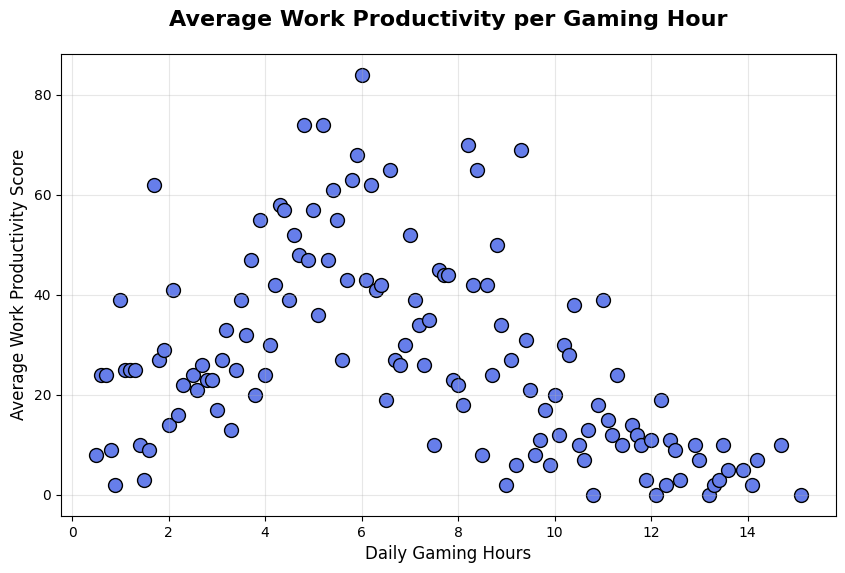

In [50]:
grouped_data = fact_table.groupby('daily_gaming_hours')['work_productivity_score'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    grouped_data['daily_gaming_hours'],
    grouped_data['work_productivity_score'],
    c='#667eea', s=100, edgecolors='black', linewidth=1
)
plt.title('Average Work Productivity per Gaming Hour', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Gaming Hours', fontsize=12)
plt.ylabel('Average Work Productivity Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
mood_state_analysis = (
    fact_table.groupby("mood_state")
    .agg(
        players=("record_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_total_spent", ascending=True)
)
mood_state_analysis

,mood_state,players,avg_total_spent,avg_gaming_hours
4,Excited,40,3109.16,3.51
6,Normal,172,4529.93,4.07
3,Euphoric,107,5929.00,5.73
0,Angry,102,6447.93,6.51
8,Withdrawn,40,6568.81,6.69
7,Restless,135,6948.93,6.75
2,Depressed,88,7321.05,6.72
5,Irritable,147,9766.89,7.02
1,Anxious,169,10225.74,7.30


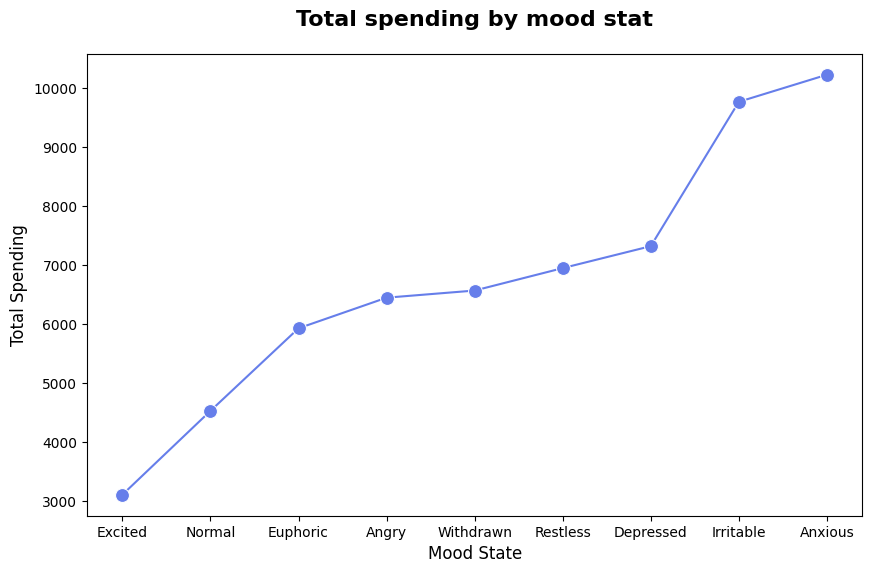

In [52]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mood_state_analysis,
    x='mood_state',
    y='avg_total_spent',
   marker='o',markersize=10, color='#667eea'
)

plt.title('Total spending by mood stat', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mood State', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.show()

In [53]:
pysical_analysis = (
    fact_table.merge(dim_physical, on="physical_id", how="inner")
    .groupby("physical_pain")
    .agg(
        players=("record_id", "count"),
        sum_total_spent=("total_spent", "sum"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("sum_total_spent", ascending=True)
)
pysical_analysis

,physical_pain,players,sum_total_spent,avg_gaming_hours
1,Low_Risk,391,1410856.08,3.95
0,High_Risk,236,2535972.00,8.28
2,Moderate,373,3257770.44,7.12


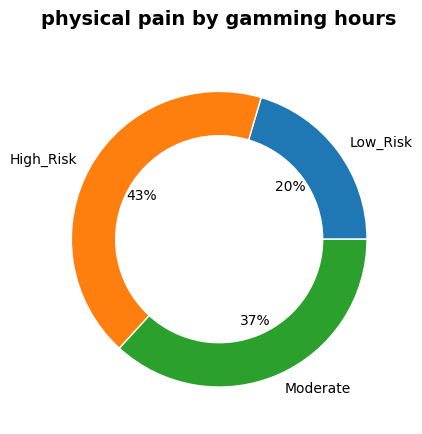

In [54]:
plt.pie(
    x=pysical_analysis["avg_gaming_hours"],
    labels=pysical_analysis["physical_pain"],
    autopct='%1.0f%%',
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}
)

plt.title("physical pain by gamming hours\n", fontsize=14, fontweight='bold')
plt.show()

# **12- Strategic Actionable Recommendations:**

1. Implement Strict Screen-Time Hard Limits
Gamers should leverage console and PC built-in digital well-being tools to enforce a maximum cap of 3 to 3.5 hours of daily gaming to protect academic performance and minimize dependency risks.

2. Adopt Sleep Hygiene & Ergonomic Break Protocols
Enforce a strict "No-Screen Buffer Hour" before bedtime to ensure better sleep quality, alongside practicing the 20-20-20 rule during active gaming sessions to reduce physical strain and eye fatigue.

3. Foster Offline Social Integration
Universities and local communities should create hybrid or physical social clubs that align with esports interests, directly helping high-risk gamers convert online screen time into real-world, face-to-face social connections.

4. Establish Automated Micro-transaction Caps
Players experiencing high impulse spending should set up automated, monthly micro-transaction boundaries directly inside their banking or payment applications to avoid gaming-induced financial stress.